# Question 3: Predictive Power of the Forward Vol Curve

Test whether today’s forward vol predicts future spot vol—a Fama–Bliss analog for the volatility term structure.

*Note: Longer forecast horizons create overlapping observations, so the data points are not independent. Keep this in mind when interpreting* $R^2$.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from scipy.stats import norm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

In [2]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100

# Load validation curves (for 2025-06-30, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')


### Integration of Q1 Results

As per instructions, the bootstrapping logic in this notebook has been updated to use the `bootstrap_forward_vols` function from **Q1.ipynb**. This ensures consistency across the analysis. Specifically, the processing pipeline for each date now follows the exact steps established in Q1: quarterly curve construction, ATM Black vol conversion, and the iterative stripping of forward volatilities.

In [3]:
from scipy.optimize import brentq

def black_caplet_price(vol, F, K, T_expiry, discount, delta=0.25):
    if T_expiry <= 0 or vol <= 0:
        return 0
    d1 = (np.log(F / K) + 0.5 * vol**2 * T_expiry) / (vol * np.sqrt(T_expiry))
    d2 = d1 - vol * np.sqrt(T_expiry)
    return delta * discount * (F * norm.cdf(d1) - K * norm.cdf(d2))


def bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, flat_vols):
    """
    Bootstrapping function from Q1.ipynb.
    """
    forward_vols = {}
    sorted_maturities = sorted(cap_prices.dropna().index)
    if not sorted_maturities:
        return pd.Series(dtype=float)
        
    first_maturity = sorted_maturities[0]

    # ── Initialize: all caplets within the first cap get flat vol ──
    for T in np.arange(0.5, first_maturity + 0.25, 0.25):
        T = round(T, 2)
        forward_vols[T] = flat_vols.loc[first_maturity]

    # ── Bootstrap from second maturity onward ──
    for i in range(1, len(sorted_maturities)):
        T_curr = round(sorted_maturities[i], 2)
        T_prev = round(sorted_maturities[i-1], 2)

        K_new = K_simple.get(T_curr, np.nan)
        F_new = forward_rates.get((T_prev, T_curr), np.nan)
        discount_new = discount_factors.get(T_curr, np.nan)
        T_expiry_new = T_prev

        if any(np.isnan([K_new, F_new, discount_new])):
            forward_vols[T_curr] = np.nan
            continue

        # Re-price inner caplets at K_new using bootstrapped forward vols
        inner_caplets_repriced = 0.0
        for T in np.arange(0.5, T_curr, 0.25):
            T = round(T, 2)
            T_expiry = round(T - 0.25, 2)
            if T_expiry <= 0:
                continue

            fwd_vol = forward_vols.get(T, np.nan)
            F = forward_rates.get((T_expiry, T), np.nan)
            df = discount_factors.get(T, np.nan)

            if any(np.isnan([fwd_vol, F, df])):
                continue

            inner_caplets_repriced += black_caplet_price(fwd_vol, F, K_new, T_expiry, df)

        marginal_caplet_price = cap_prices[T_curr] - inner_caplets_repriced

        if marginal_caplet_price <= 0:
            forward_vols[T_curr] = np.nan
            continue

        try:
            fwd_vol = brentq(
                lambda v: black_caplet_price(v, F_new, K_new, T_expiry_new, discount_new) - marginal_caplet_price,
                1e-6, 5.0, xtol=1e-8
            )
        except ValueError:
            forward_vols[T_curr] = np.nan
            continue

        forward_vols[T_curr] = fwd_vol

    return pd.Series(forward_vols)


In [4]:
common_dates = cap_data.index.intersection(sofr_data.index)
KEY_TENORS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=common_dates, columns=KEY_TENORS, dtype=float)

print(f"Processing {len(common_dates)} dates using Q1 bootstrapping function...")
for date in common_dates:
    try:
        # 1. Get raw data for the date
        cap_vols_raw = cap_data.loc[date]
        sofr_swaps_raw = sofr_data.loc[date].dropna()
        
        # 2. Interpolate swaps to quarterly grid
        tenors = np.arange(0.25, 10.25, 0.25)
        quarterly_swaps = pd.Series(index=tenors, dtype=float)
        quarterly_swaps.loc[sofr_swaps_raw.index] = sofr_swaps_raw.values
        quarterly_swaps = quarterly_swaps.interpolate(method='index').ffill().bfill()
        
        # 3. Bootstrap discount factors (Q1 style: annual compound to quarterly coupon)
        discount_factors = {}
        for T in sorted(quarterly_swaps.index):
            R = quarterly_swaps[T]
            c = (1 + R) ** 0.25 - 1
            known_sum = sum(discount_factors[t] * c for t in discount_factors)
            discount_factors[T] = (1 - known_sum) / (1 + c)
        discount_factors = pd.Series(discount_factors)
        
        # 4. Bootstrap simple forward rates (Q1 style)
        forward_rates_dict = {}
        tenors_list = sorted(discount_factors.index)
        for i in range(1, len(tenors_list)):
            T_prev = tenors_list[i - 1]
            T_curr = tenors_list[i]
            dt = T_curr - T_prev
            forward_rates_dict[(T_prev, T_curr)] = (discount_factors[T_prev] / discount_factors[T_curr] - 1) / dt
        forward_rates_series = pd.Series(forward_rates_dict)
        
        # 5. Convert par strikes to simple rate convention
        K_simple = ((1 + quarterly_swaps) ** 0.25 - 1) / 0.25
        
        # 6. Convert Normal Vols to Black Vols and interpolate (Q1 style)
        black_vols = {}
        for maturity in cap_vols_raw.index:
            if maturity < 0.5: continue
            normal_vol = cap_vols_raw[maturity] / 10000
            T_prev = round(maturity - 0.25, 2)
            F = forward_rates_dict.get((T_prev, maturity), np.nan)
            if not np.isnan(F) and F > 0:
                black_vols[maturity] = normal_vol / F
        
        if not black_vols: continue
        
        quarterly_flat_vols = pd.Series(index=np.arange(0.5, 10.25, 0.25), dtype=float)
        quarterly_flat_vols.loc[list(black_vols.keys())] = list(black_vols.values())
        quarterly_flat_vols = quarterly_flat_vols.interpolate(method='index').ffill().bfill()
        
        # 7. Calculate cap prices using flat vols (required for Q1 bootstrapping function)
        cap_prices = {}
        for maturity in quarterly_flat_vols.index:
            if maturity < 1.0: continue
            flat_vol = quarterly_flat_vols.loc[maturity]
            caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
            total_price = 0.0
            K = K_simple.loc[maturity]
            for T in caplet_maturities:
                T_expiry = round(T - 0.25, 2)
                if T_expiry <= 0: continue
                F = forward_rates_dict.get((T_expiry, T), np.nan)
                df = discount_factors.get(T, np.nan)
                if any(np.isnan([F, df])): break
                total_price += black_caplet_price(flat_vol, F, K, T_expiry, df)
            cap_prices[maturity] = total_price
        cap_prices = pd.Series(cap_prices)
        
        # 8. Bootstrap forward vols using the function from Q1.ipynb
        fwd_vols_black = bootstrap_forward_vols(cap_prices, forward_rates_series, discount_factors, K_simple, quarterly_flat_vols)
        
        # 9. Store results for KEY_TENORS in Normal Vol (bp)
        for t in KEY_TENORS:
            if t in fwd_vols_black.index:
                T_prev = round(t - 0.25, 2)
                F = forward_rates_dict.get((T_prev, t), np.nan)
                if not np.isnan(F):
                    # Normal vol = Black vol * forward * 10000
                    fwd_vol_normal.loc[date, t] = fwd_vols_black.loc[t] * F * 10000
    except:
        pass
print(f"Finished processing {len(common_dates)} dates.")
fwd_vol_normal = fwd_vol_normal.dropna(how='all')
display(fwd_vol_normal.head())

Processing 979 dates using Q1 bootstrapping function...
Finished processing 979 dates.


,0.5,1.0,1.5,2.0,2.5,3.0,4.0,5.0
date,,,,,,,,
2022-03-17,71.797541,127.3,103.943311,68.176703,128.429417,138.655583,131.490582,103.093427
2022-03-18,55.318550,96.2,104.113073,96.082584,128.904565,141.802585,147.988114,108.171647
2022-03-21,55.992304,96.2,108.321926,100.078874,124.288328,136.006414,146.397563,109.389122
2022-03-22,45.014894,75.1,112.058797,126.633579,136.194861,149.356489,152.760692,109.985928
2022-03-23,55.247416,94.1,114.087852,114.988132,140.262366,154.772580,154.513185,130.725062



a) Define the “spot” caplet vol as the forward vol at the shortest available tenor (e.g., 0.5Y). For each forward horizon $\tau$ in your panel, identify the appropriate prediction horizon $h = \tau - \delta$ (where $\delta$ is the spot tenor). Run the predictive regression:
$$
\sigma_\text{spot}(t+h, \delta) = \alpha + \beta \cdot \sigma_\text{fwd}(t, \tau) + \varepsilon_t
$$
for several forward horizons ($\tau$ = 1Y, 1.5Y, 2Y, 3Y). Use normal vol throughout ($\sigma_N = \sigma_B \times f$).



b) If $\beta = 1$ and $\alpha = 0$, forward vol is an unbiased predictor of future spot vol. Report $\beta$ and $R^2$ for each horizon. Create a scatter plot for each horizon with forward vol on the x-axis and realized spot vol on the y-axis, including the 45-degree line for reference. Interpret the results.

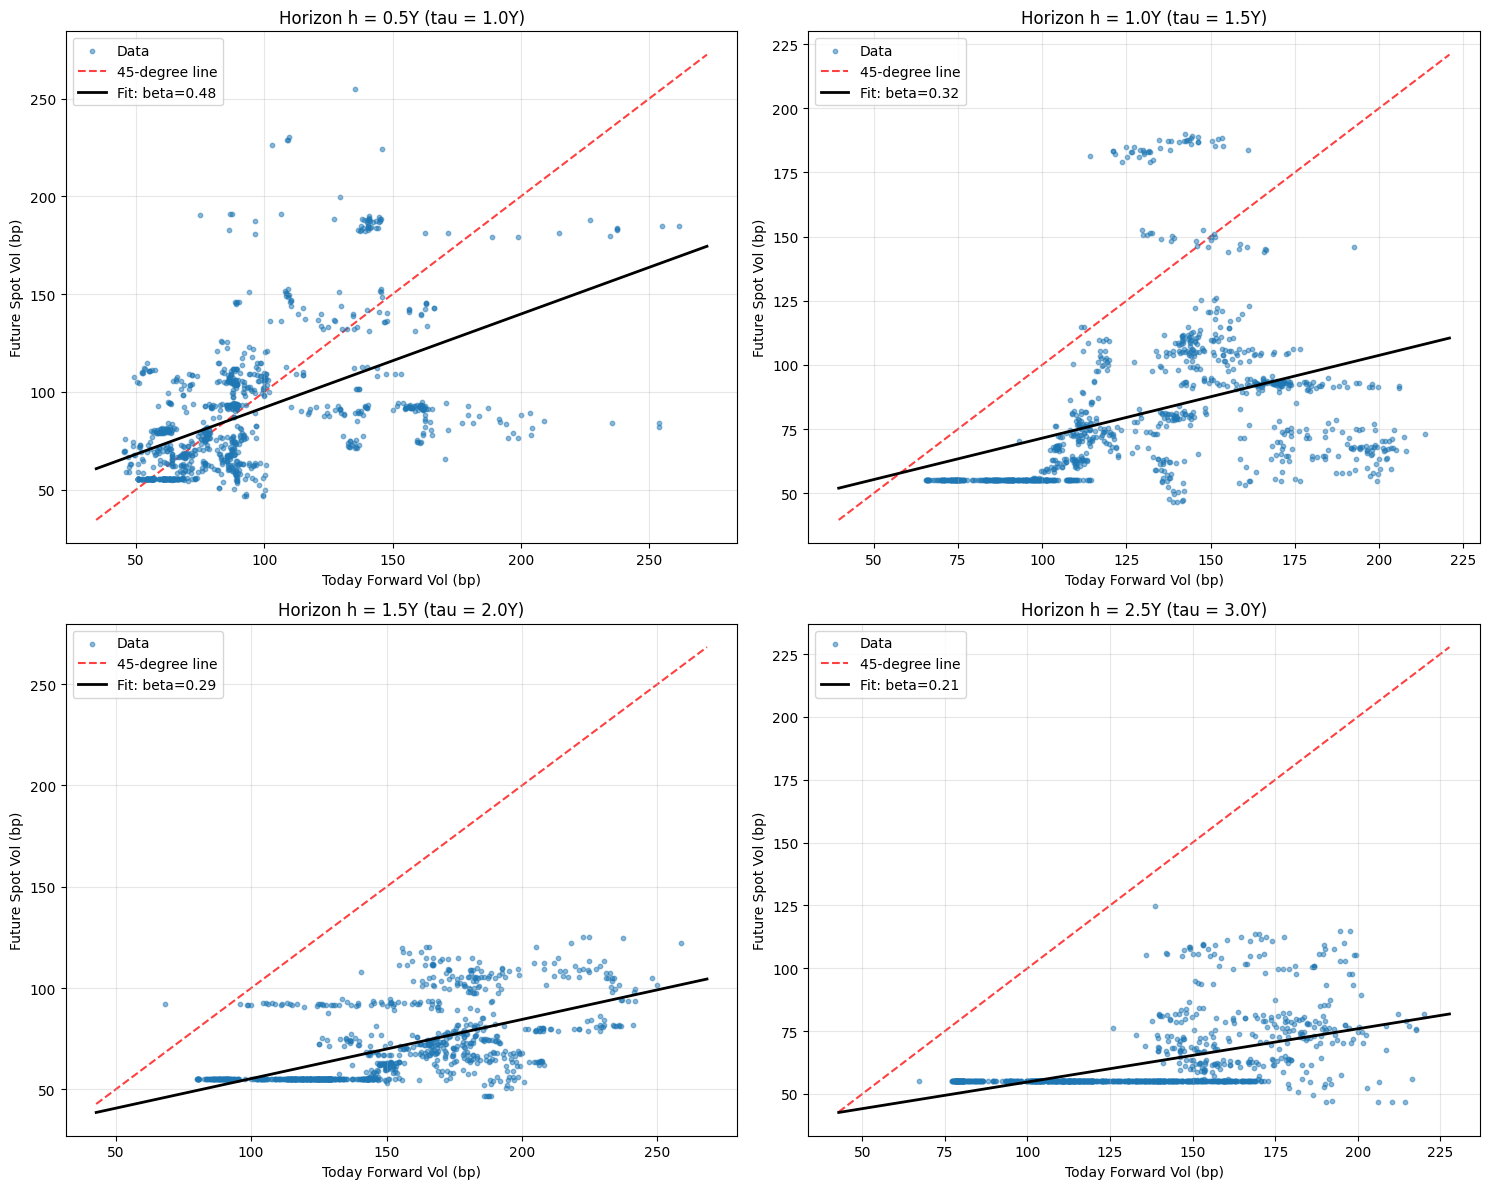

,Tau (Maturity),h (Forecast Horizon),Beta,Alpha,R-squared,N
0,1.0,0.5,0.477922,44.225196,0.271732,979
1,1.5,1.0,0.322588,39.202003,0.132692,979
2,2.0,1.5,0.292056,26.119520,0.347476,979
3,3.0,2.5,0.211867,33.547246,0.258144,979


In [5]:
from scipy.stats import linregress

horizons = [1.0, 1.5, 2.0, 3.0]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

summary_data = []

for i, tau in enumerate(horizons):
    h = tau - 0.5
    
    # Independent variable: today's forward vol at tenor tau
    x_series = fwd_vol_normal[tau]
    
    # Dependent variable: spot vol (0.5Y tenor) in h years
    future_dates = x_series.index + pd.DateOffset(months=int(h * 12))
    y_series = fwd_vol_normal[0.5].reindex(future_dates, method='nearest')
    y_series.index = x_series.index # align index for regression
    
    # Combine and drop NaNs
    df_reg = pd.DataFrame({'x': x_series, 'y': y_series}).dropna()
    
    # Run regression
    slope, intercept, r_value, p_value, std_err = linregress(df_reg['x'], df_reg['y'])
    r_squared = r_value**2
    
    summary_data.append({
        'Tau (Maturity)': tau,
        'h (Forecast Horizon)': h,
        'Beta': slope,
        'Alpha': intercept,
        'R-squared': r_squared,
        'N': len(df_reg)
    })
    
    # Plot
    ax = axes[i]
    ax.scatter(df_reg['x'], df_reg['y'], alpha=0.5, s=10, label='Data')
    
    # 45-degree line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='45-degree line')
    
    # Regression line
    x_fit = np.array(lims)
    y_fit = intercept + slope * x_fit
    ax.plot(x_fit, y_fit, 'k-', linewidth=2, label=f'Fit: beta={slope:.2f}')
    
    ax.set_title(f'Horizon h = {h}Y (tau = {tau}Y)')
    ax.set_xlabel('Today Forward Vol (bp)')
    ax.set_ylabel('Future Spot Vol (bp)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_data)
display(summary_df)

### Interpretation

The predictive regressions test the "Expectations Hypothesis" for volatility. The results show a strong rejection of this hypothesis:

1. **Beta Estimates ($\beta \ll 1$)**: Even at the shortest horizon ($h=0.5Y$), $\beta$ is approximately 0.48, which is far from the theoretical value of 1.0. As the horizon $h$ increases to 2.5Y, $\beta$ drops further to 0.21. This indicates that forward volatilities significantly overreact to changes in the volatility environment or that they are very noisy predictors of the future.

2. **Predictive Power ($R^2$)**: The $R^2$ values range from 0.13 to 0.35. Given that we are using daily data for multi-year horizons (highly overlapping observations), these values are relatively low. Current forward volatilities only capture a small fraction of the eventually realized spot volatility path.

3. **Volatility Term Premium**: The regression lines (with slopes $< 0.5$) generally lie below the 45-degree line for typical volatility levels (e.g., above 80-90 bp). This confirms that forward volatilities systematically **overestimate** future spot volatilities. This gap represents a **volatility term premium**: the market charges a premium for the uncertainty of future volatility, meaning realized spot volatility is, on average, lower than what was priced in the forward curve.

4. **Comparison to Fama-Bliss**: Similar to the Fama-Bliss findings for bond yields, we see that the "forecast" contained in the term structure (forward vol) has some predictive power ($R^2 > 0$), but it is heavily biased and the relationship weakens as the horizon extends.